# Geological Surface Accuracy
NB usa il kernel geoai (Python 3.12.10)

In [1]:
# Importazione delle librerie necessarie
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiPoint, MultiLineString
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.tri import Triangulation
import matplotlib.colors as mcolors
from matplotlib import cm

#############################################################################################
## Importa funzioni
import importlib # modulo per il reload delle funzioni

# Reimporta i moduli originali
import files_utils


# Ricarica forzata di ciascun modulo
importlib.reload(files_utils)


# Reimporta le funzioni dai moduli ricaricati
from files_utils import *

#############################################################################################


In [2]:
# ### Impostazione delle cartella di lavoro
working_dir = "working_files_folder"
output_dir = "output_results"
crs = 'EPSG:6708'

Avvio dell'analisi dei dati geologici...
File presenti nella cartella working_files_folder:
  - files_description.txt
  - horizons.ts
  - linee_sismiche.cpg
  - linee_sismiche.dbf
  - linee_sismiche.prj
  - linee_sismiche.sbn
  - linee_sismiche.sbx
  - linee_sismiche.shp
  - linee_sismiche.shp.xml
  - linee_sismiche.shx
  - pozzi_idrocarburi.cpg
  - pozzi_idrocarburi.dbf
  - pozzi_idrocarburi.prj
  - pozzi_idrocarburi.sbn
  - pozzi_idrocarburi.sbx
  - pozzi_idrocarburi.shp
  - pozzi_idrocarburi.shp.xml
  - pozzi_idrocarburi.shx
Lettura del file GOCAD .ts: horizons.ts
File working_files_folder\horizons.ts aperto con successo. Lettura di 113884 linee.
Trovati 44519 vertici e 69225 triangoli nel file.
Forma dell'array vertices: (44519, 3)
Letti 44519 vertici e 69225 triangoli.
Forma dell'array vertices: (44519, 3)
Lettura dello shapefile dei pozzi: pozzi_idrocarburi.shp
Confermato: lo shapefile contiene punti (pozzi).
Colonne disponibili nello shapefile dei pozzi: ['OBJECTID', 'GISID', 'N

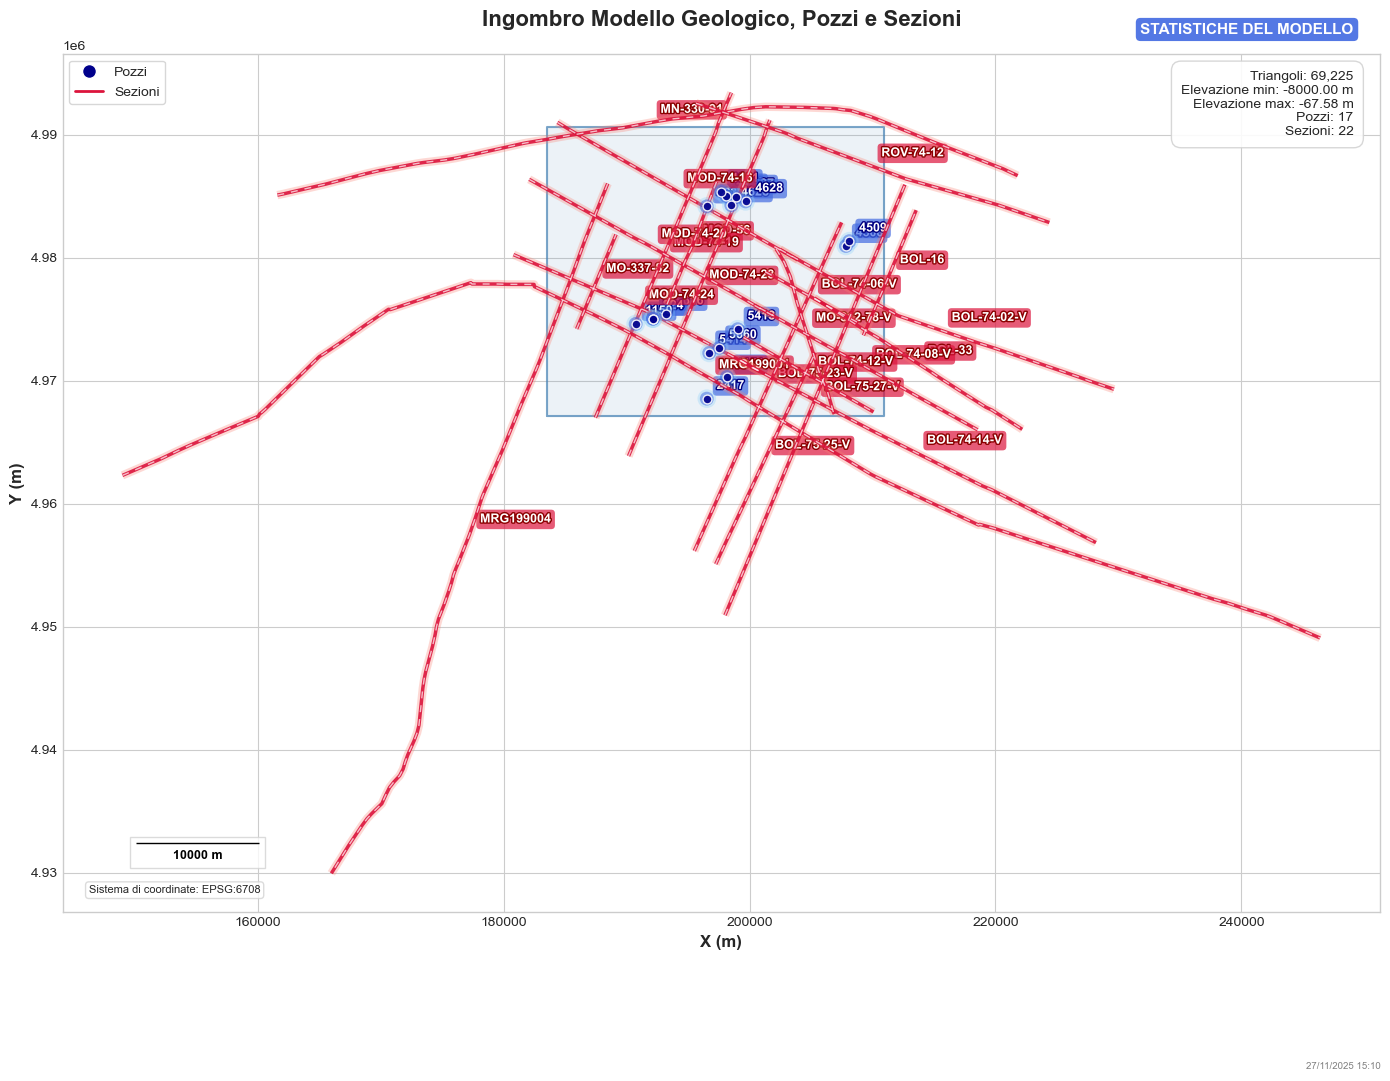

Visualizzazione completata con successo.
Analisi completata.


In [3]:
# Main Function ed esecuzione procedura
def main(working_dir=working_dir):
    print("Avvio dell'analisi dei dati geologici...")

    # Controlla se la cartella di lavoro esiste
    if not os.path.exists(working_dir):
        print(f"La cartella {working_dir} non esiste. Creazione in corso...")
        os.makedirs(working_dir)
        print(f"Cartella {working_dir} creata. Inserisci i file GOCAD .ts e gli shapefile nella cartella.")
        return None

    # Stampa i file presenti nella cartella di lavoro
    print(f"File presenti nella cartella {working_dir}:")
    for file in os.listdir(working_dir):
        print(f"  - {file}")

    # Leggi il file GOCAD .ts - pass working_dir as parameter
    vertices, triangles = process_gocad_file(working_dir)

    # Leggi lo shapefile dei pozzi - pass working_dir as parameter
    wells_shp = read_wells_shapefile(working_dir)

    # Leggi lo shapefile delle sezioni - pass working_dir as parameter
    sections_shp = read_sections_shapefile(working_dir)

    # Verifica la presenza dei dati prima della visualizzazione
    has_vertices = vertices is not None and len(vertices) > 0
    has_triangles = triangles is not None and len(triangles) > 0
    has_wells = wells_shp is not None and not wells_shp.empty
    has_sections = sections_shp is not None and not sections_shp.empty

    print(f"Stato dei dati:")
    print(f"  - Vertices: {'Presenti' if has_vertices else 'Assenti'} - {len(vertices) if has_vertices else 0} vertici")
    print(f"  - Triangoli: {'Presenti' if has_triangles else 'Assenti'} - {len(triangles) if has_triangles else 0} triangoli")
    print(f"  - Pozzi: {'Presenti' if has_wells else 'Assenti'}")
    print(f"  - Sezioni: {'Presenti' if has_sections else 'Assenti'}")

    # Visualizza i dati solo se almeno uno dei dataset è presente
    if has_vertices or has_wells or has_sections:
        try:
            fig = visualize_data(vertices, triangles, wells_shp, sections_shp, apply_smoothing=False, 
                                 smoothing_iterations=3, smoothing_factor=0.2, crs='EPSG:6708',
                                 output_filename='model_dataset.png')
            print("Visualizzazione completata con successo.")
        except Exception as e:
            print(f"Errore durante la visualizzazione: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("Non ci sono dati da visualizzare. Verifica che i file siano presenti nella cartella di lavoro.")

    print("Analisi completata.")

    # Ritorna i dati letti per eventuali ulteriori analisi
    return {
        'vertices': vertices,
        'triangles': triangles,
        'wells': wells_shp,
        'sections': sections_shp
    }

# Esegui la Main Function
if __name__ == "__main__":
    data = main()

